In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.inspection import DecisionBoundaryDisplay

In [3]:
data = load_breast_cancer()
X = data.data
y = data.target

print("Shape of X:", X.shape)

Shape of X: (569, 30)


In [4]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
# 2d for visualization
pca_2d = PCA(n_components=2)
X_train_2d = pca_2d.fit_transform(X_train_scaled)
X_test_2d = pca_2d.transform(X_test_scaled)

print(f"Variance explained by the first two principal components: {np.sum(pca_2d.explained_variance_ratio_)*100:.2f}%")

Variance explained by the first two principal components: 63.00%


In [11]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'gamma': ['scale', 'auto']
}
grid_2d = GridSearchCV(SVC(kernel='rbf'), param_grid, cv=5)
grid_2d.fit(X_train_2d, y_train)

best_model_2d = grid_2d.best_estimator_
print("Model test score:", best_model_2d.score(X_test_2d, y_test))

Model test score: 0.9736842105263158


<Figure size 800x600 with 0 Axes>

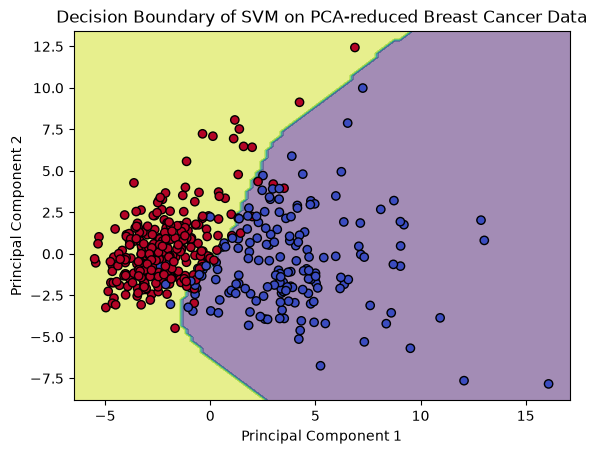

In [12]:
# Plot decision boundary
plt.figure(figsize=(8, 6))
DecisionBoundaryDisplay.from_estimator(best_model_2d, X_train_2d, response_method="predict", alpha=0.5,
                                xlabel='Principal Component 1', ylabel='Principal Component 2')

plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, edgecolor='k', cmap=plt.cm.coolwarm)
plt.title('Decision Boundary of SVM on PCA-reduced Breast Cancer Data')
plt.show()

In [15]:
# 95% Variance Preservation PCA
pca_optimal = PCA(n_components=0.95)
X_train_optimal = pca_optimal.fit_transform(X_train_scaled)
X_test_optimal = pca_optimal.transform(X_test_scaled)

print(f"Number of components to preserve 95% variance: {pca_optimal.n_components_}")
print(f"Original number of features: {X_train_scaled.shape[1]}")

Number of components to preserve 95% variance: 10
Original number of features: 30


In [14]:
grid_optimal = GridSearchCV(SVC(kernel='rbf'), param_grid, cv=5)
grid_optimal.fit(X_train_optimal, y_train)

print("Best parameters found for optimal PCA:", grid_optimal.best_params_)
print("Model test score with optimal PCA:", grid_optimal.best_estimator_.score(X_test_optimal, y_test))

Best parameters found for optimal PCA: {'C': 1, 'gamma': 'scale'}
Model test score with optimal PCA: 0.9649122807017544
